<a href="https://colab.research.google.com/github/harshsalvi1810/PythonProgramming/blob/main/EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# import data manipulation library
import numpy as np
import pandas as pd


# import data visualization library
import matplotlib.pyplot as plt
import seaborn as sns

# import logging
import logging
logging.basicConfig(level = logging.INFO,
                    filemode = 'w',
                    filename = 'model.log',
                    format = '%(asctime)s - %(message)s',
                    force = True)

In [19]:
logging.info('EDA Process Started')

In [20]:
try:
  df = pd.read_csv('/content/titanic_dataset - titanic_dataset.csv')
except:
  print('File not found')

In [21]:
df.sample(frac = 1)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Nationality,Occupation,FamilySize,IsAlone,Deck,Title,AgeGroup,TravelPurpose,Survived
9740,9741,1,"Khan, Mrs. David Anna",female,41.0,1,0,7OBTVD2,121.03,NaN,C,Lebanon,Clerk,2,0,Unknown,Mrs,Adult,Immigration,1
1908,1909,3,"Lee, Dr. Ali Emma",male,23.7,3,2,BK8ELBB,14.05,NaN,Q,Italy,Merchant,6,0,Unknown,Dr,Adult,Vacation,0
9781,9782,1,"Garcia, Mr. David John",male,28.4,2,1,M9659MQ,66.42,NaN,S,Ireland,Clerk,4,0,Unknown,Mr,Adult,Business,0
6027,6028,3,"Brown, Mr. Raj Raj",male,30.6,2,0,AUFZ8XT,10.08,NaN,S,Sweden,Merchant,3,0,Unknown,Mr,Adult,Family Visit,1
3467,3468,3,"Murphy, Mr. David Emma",male,30.2,3,1,VJG0H7T,6.16,NaN,Q,France,Nurse,5,0,Unknown,Mr,Adult,Business,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1732,1733,3,"Khan, Mr. Mary David",male,24.6,3,1,VIXBMOY,19.68,NaN,Q,Ireland,Engineer,5,0,Unknown,Mr,Adult,Immigration,0
9422,9423,3,"Johnson, Miss. John John",female,31.5,1,0,FUQH51I,28.51,NaN,S,Germany,Engineer,2,0,Unknown,Miss,Adult,Immigration,0
3954,3955,2,"Patel, Dr. Emma David",male,11.6,0,1,PTR8ZFO,43.15,NaN,C,Italy,Clerk,2,0,E,Dr,Child,Business,0
4784,4785,3,"Johnson, Master. James Anna",male,37.4,1,0,S6CF1EA,12.11,NaN,S,Italy,Seamstress,2,0,Unknown,Master,Adult,Vacation,0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    10000 non-null  int64  
 1   Pclass         10000 non-null  int64  
 2   Name           10000 non-null  object 
 3   Sex            10000 non-null  object 
 4   Age            10000 non-null  float64
 5   SibSp          10000 non-null  int64  
 6   Parch          10000 non-null  int64  
 7   Ticket         10000 non-null  object 
 8   Fare           10000 non-null  float64
 9   Cabin          1807 non-null   object 
 10  Embarked       10000 non-null  object 
 11  Nationality    10000 non-null  object 
 12  Occupation     10000 non-null  object 
 13  FamilySize     10000 non-null  int64  
 14  IsAlone        10000 non-null  int64  
 15  Deck           10000 non-null  object 
 16  Title          10000 non-null  object 
 17  AgeGroup       10000 non-null  object 
 18  TravelP

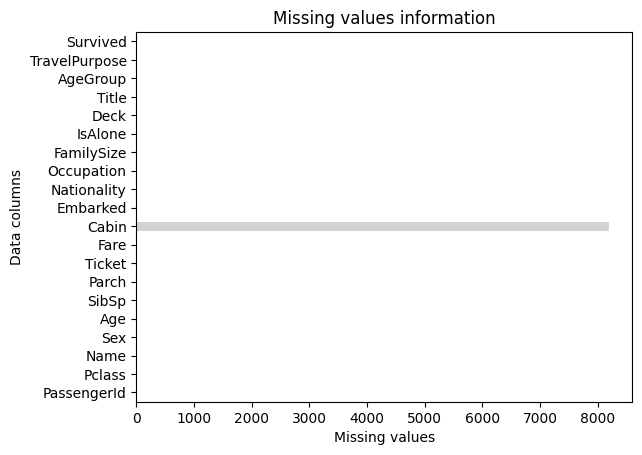

In [23]:
# Missing values information using graph

df.isnull().sum().plot(kind = 'barh',color = 'lightgray')
plt.ylabel('Data columns')
plt.xlabel('Missing values')
plt.title('Missing values information')
plt.show()

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
# Segregate categorical and numerical
categorical_data = df.select_dtypes(include = 'object')
categorical_data

,Name,Sex,Ticket,Cabin,Embarked,Nationality,Occupation,Deck,Title,AgeGroup,TravelPurpose
0,"Patel, Mr. Raj Mary",male,JF8W5KN,NaN,S,Ireland,Doctor,Unknown,Mr,Adult,Immigration
1,"Lee, Mr. David Emma",male,R8TGFOF,NaN,S,Finland,Labourer,Unknown,Mr,Adult,Immigration
2,"Khan, Dr. Raj James",male,8L01TIK,NaN,S,USA,Doctor,Unknown,Dr,Adult,Business
3,"Murphy, Dr. Emma John",female,QFW2X6G,NaN,S,England,Labourer,B,Dr,Adult,Family Visit
4,"Murphy, Mrs. Emma Ali",female,X27TNTW,NaN,S,Lebanon,Merchant,Unknown,Mrs,Adult,Family Visit
...,...,...,...,...,...,...,...,...,...,...,...
9995,"Khan, Master. James Raj",male,EVLM0GX,G112,S,Italy,Seamstress,G,Master,Adult,Business
9996,"Garcia, Mrs. James James",female,IDPZCK8,NaN,Q,Ireland,Student,Unknown,Mrs,Adult,Vacation
9997,"Patel, Miss. Ali Emma",female,SNK8PXF,NaN,S,Italy,Teacher,Unknown,Miss,Adult,Immigration
9998,"Khan, Dr. David David",male,8Y7DJ12,G95,S,France,Engineer,G,Dr,Adult,Immigration


In [28]:
numerical_data = df.select_dtypes(exclude = 'object')
numerical_data

,PassengerId,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Survived
0,1,3,20.1,2,1,36.44,4,0,0
1,2,3,41.7,0,0,26.74,1,1,0
2,3,3,20.0,3,1,15.67,5,0,0
3,4,2,38.6,1,0,35.72,2,0,1
4,5,3,40.9,0,1,23.99,2,0,0
...,...,...,...,...,...,...,...,...,...
9995,9996,1,24.0,3,1,129.02,5,0,1
9996,9997,3,22.2,2,0,27.65,3,0,1
9997,9998,1,23.8,2,2,86.84,5,0,1
9998,9999,1,32.2,3,0,96.99,4,0,1


Observations:

1. The dataset contains 10k rows and 20 columns

2. Out of 20 columns 09 best features selected based on domain knowledge

  - Sex, Embarked, Pclass, Age, Sibsp, Parch, Familysize, isAlone and Survived

3. Considering Sex and Embarked both are Nominal data so we can encode with     label encoding i.e. Converting Categorical data into numerical data

4. Based on Numerical Descriptive stats it was observed that all numerical columns are showing non normal disrtribution

In [31]:
from typing import OrderedDict
# Checking Descriptive Stats using ordereddict function

from collections import OrderedDict

stats = []


for i in df.select_dtypes(exclude = 'object'):
  numerical_stats = OrderedDict({
      'Feature' : i,
      'Count' : df[i].count(),
      'Max' : df[i].max(),
      'Min' : df[i].min(),
      'Mean' : df[i].mean(),
      'Median' : df[i].median(),
      'Q1' : df[i].quantile(0.25),
      'Q3' : df[i].quantile(0.75),
      'IQR' : df[i].quantile(0.75) - df[i].quantile(0.25),
      'Outliers' : df[i],
      'Skewness' : df[i].skew(),
      'Kurtosis' : df[i].kurtosis()
  })

  stats.append(numerical_stats)
  report = pd.DataFrame(stats)

report

,Feature,Count,Max,Min,Mean,Median,Q1,Q3,IQR,Outliers,Skewness,Kurtosis
0,PassengerId,10000,10000.00,1.00,5000.500000,5000.500,2500.75,7500.250,4999.500,0 1 1 2 2 3 3 ...,0.000000,-1.200000
1,Pclass,10000,3.00,1.00,2.321600,3.000,2.00,3.000,1.000,0 3 1 3 2 3 3 2 4 ...,-0.658505,-1.235643
2,Age,10000,80.00,0.50,30.229990,30.300,20.60,39.600,19.000,0 20.1 1 41.7 2 20.0 3 ...,0.086564,-0.256993
3,SibSp,10000,3.00,0.00,1.516300,2.000,1.00,3.000,2.000,0 2 1 0 2 3 3 1 4 ...,-0.016401,-1.362975
4,Parch,10000,2.00,0.00,0.998600,1.000,0.00,2.000,2.000,0 1 1 0 2 1 3 0 4 ...,0.002552,-1.477132
5,Fare,10000,199.93,5.01,51.288822,32.695,19.64,66.405,46.765,0 36.44 1 26.74 2 15.67 3...,1.531927,1.408500
6,FamilySize,10000,6.00,1.00,3.514900,4.000,3.00,5.000,2.000,0 4 1 1 2 5 3 2 4 ...,-0.024748,-0.782460
7,IsAlone,10000,1.00,0.00,0.083800,0.000,0.00,0.000,0.000,0 0 1 1 2 0 3 0 4 ...,3.004554,7.028753
8,Survived,10000,1.00,0.00,0.458800,0.000,0.00,1.000,1.000,0 0 1 0 2 0 3 1 4 ...,0.165387,-1.973042


In [32]:
df.describe(include = 'object')

,Name,Sex,Ticket,Cabin,Embarked,Nationality,Occupation,Deck,Title,AgeGroup,TravelPurpose
count,10000,10000,10000,1807,10000,10000,10000,10000,10000,10000,10000
unique,3019,2,10000,855,3,10,10,8,5,4,4
top,"Martin, Dr. Ali Anna",female,ESG1YPF,C20,S,Germany,Engineer,Unknown,Dr,Adult,Immigration
freq,15,5014,1,7,7058,1076,1046,6459,3348,7491,2552


In [33]:
df.groupby('Sex')['Fare'].mean()

,Fare
Sex,
female,50.979880
male,51.599499


In [34]:
df.groupby('Sex')['Age'].mean()

,Age
Sex,
female,30.460052
male,29.998636


<Figure size 1000x1000 with 0 Axes>

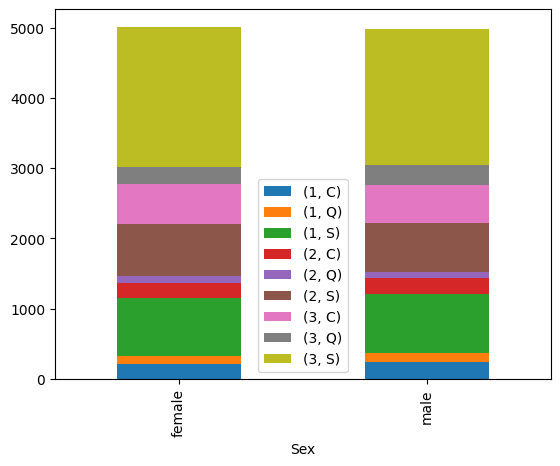

In [48]:
plt.figure(figsize = (10,10))
pd.crosstab(index = [df['Sex']], columns = [df['Pclass'],df['Embarked']]).plot(kind = 'bar',stacked = True)
plt.legend()
plt.show()